# Lab Assignment 4: Support Vector Machines

In this exercise, we return to the wine quality dataset. However, this time, we will attempt to separate various pieces of cloathing using a Support Vector Machine (SVM). Below, we gather the data and preprocess it for you. As your task, you need to implement an SVM solver, perform finetuning and classification, and finally, show your results using a confusion matrix.

## Library installation
In this lab we will use the `cvxopt` package, [whose documentation can be found here](https://cvxopt.org/userguide/index.html).

We are running version 1.3.2 of `cvxopt`.

In [27]:
!pip install cvxopt

### Package Imports

In [28]:
## =======================================================
## Import Key Packages
## =======================================================
## Standard Fare
import numpy as np
from scipy.io import loadmat

## CVX Opt
import cvxopt
from cvxopt import solvers
from cvxopt import matrix
from sklearn.model_selection import train_test_split
import pandas as pd

solvers.options['show_progress'] = False

## Accessing the Data

In [29]:
training_data = pd.read_csv('./fashion-mnist_train.csv')

y = training_data['label']
X = training_data.drop('label',axis=1)

X = X[:2000]
y = y[:2000]

train_samples, test_samples, train_samples_labels, test_samples_labels = train_test_split(X, y, test_size=0.1, random_state=42, shuffle=True)

test_samples_labels=np.squeeze(test_samples_labels)
train_samples_labels=np.squeeze(train_samples_labels)

In [30]:
label_to_title = {0: 'T-shirt/top', 
                  1:'Trouser', 
                  2:'Pullover', 
                  3:'Dress', 
                  4:'Coat', 
                  5:'Sandal',
                  6:'Shirt', 
                  7:'Sneaker', 
                  8:'Bag',
                  9:'Ankle boot'}

In [31]:
print(np.unique(train_samples_labels))
print(np.unique(test_samples_labels))

for i in np.unique(train_samples_labels):
    print(f' There are {sum(train_samples_labels==i)} instances of label #{i}:{label_to_title[i]} in the Train dataset')

[0 1 2 3 4 5 6 7 8 9]
[0 1 2 3 4 5 6 7 8 9]
 There are 197 instances of label #0:T-shirt/top in the Train dataset
 There are 182 instances of label #1:Trouser in the Train dataset
 There are 187 instances of label #2:Pullover in the Train dataset
 There are 190 instances of label #3:Dress in the Train dataset
 There are 200 instances of label #4:Coat in the Train dataset
 There are 160 instances of label #5:Sandal in the Train dataset
 There are 188 instances of label #6:Shirt in the Train dataset
 There are 165 instances of label #7:Sneaker in the Train dataset
 There are 168 instances of label #8:Bag in the Train dataset
 There are 163 instances of label #9:Ankle boot in the Train dataset


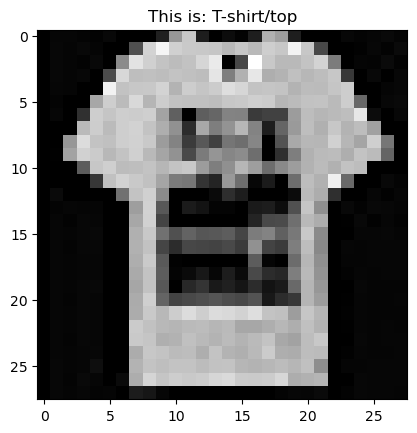

In [32]:
import matplotlib.pyplot as plt
import random

ind = random.randint(0,2000)
plt.imshow(X[ind:ind+1].values.reshape(28,28),cmap='gray')
plt.title(f'This is: {label_to_title[y[ind:ind+1].values[0]]}')
plt.show()

## Task 1:
Develop code for training an SVM for binary classification with nonlinear kernels. You'll need to accomodate non-overlapping class distributions. One way to implement this is to maximize (7.32) subject to (7.33) and (7.34) [in Bishop](https://www.microsoft.com/en-us/research/uploads/prod/2006/01/Bishop-Pattern-Recognition-and-Machine-Learning-2006.pdf). It may be helpful to redefine these as matrix operations. Let ${1}\in\mathbb{R}^{N\times 1}$ be the vector whose entries are all 1's. Let $\mathbf{a}\in\mathbb{R}^{N\times 1}$ have entries $a_i$. Let $\mathbf{T}\in\mathbb{R}^{N\times N}$ be a diagonal matrix with $\mathbf{T}_{ii} = t_i$ on the diagonal. Then we can reformulate the objective to be

\begin{equation*}
\begin{aligned}
& \text{maximize}
& & \tilde{L}(\mathbf{a}) = {1}^{\mathrm{T}}\mathbf{a} - \frac{1}{2} \mathbf{a}^{\mathrm{T}} \mathbf{T}\mathbf{K} \mathbf{T}\mathbf{a} \\
& \text{subject to}
& & {1}^{\mathrm{T}} \mathbf{a} \preceq C \\
& & & {1}^{\mathrm{T}} \mathbf{a} \succeq 0 \\
& & & \mathbf{a}^{\mathrm{T}} \mathbf{t} = 0
\end{aligned}
\end{equation*}

The "$\preceq$" symbol here means element-wise comparison. This formulation is very close to what `cvxopt` expects.

Hint (`cvxopt` expects the following form):

\begin{equation*}
\begin{aligned}
& \text{minimize}
& & \tilde{L}(\mathbf{a}) = \frac{1}{2} \mathbf{a}^{\mathrm{T}} \mathbf{T}\mathbf{K} \mathbf{T}\mathbf{a} - {1}^{\mathrm{T}}\mathbf{a} \\
& \text{subject to}
& & G \mathbf{a} \preceq h \\
& & & {\mathbf{t}}^{\mathrm{T}}\mathbf{a} = 0
\end{aligned}
\end{equation*}

where $G$ is an $N\times N$ identity matrix ontop of $-1$ times an $N\times N$ identity matrix and $h \in\mathbb{R}^{2N}$ where the first $N$ entries are $C$ and the second $N$ enties are $0$.

## Task 2:
Develop code to predict the $\{-1,+1\}$ class for new data. To use the predictive model (7.13) you need to determine $b$, which can be done with (7.37). 

We have provided some starter code in the cells below

In [33]:
def nonlinear_kernel(X, Y, degree=2, coef0=1.0):
    """
    Polynomial kernel: K(x, y) = (x·y / n_features + coef0)^degree

    Dividing by n_features keeps dot products bounded (avoids numerical issues
    when features are normalized to [0, 1]).

    Parameters
    ----------
    X : ndarray of shape (n_x, n_features)
    Y : ndarray of shape (n_y, n_features)

    Returns
    -------
    K : ndarray of shape (n_x, n_y)
    """
    return (np.dot(X, Y.T) / X.shape[1] + coef0) ** degree


In [34]:
class SVM(object):

    def __init__(self, kernel=nonlinear_kernel, C=1.0):
        """
        Parameters
        ----------
        kernel : callable — kernel(X, Y) -> (n_x, n_y) kernel matrix
        C      : float   — regularization; higher C = less margin slack
        """
        self.kernel = kernel
        self.C = C

    def fit(self, X, y):
        """
        Solve the soft-margin SVM dual (Bishop 7.32-7.34) via cvxopt QP.

        minimize    (1/2) a^T (T K T) a  -  1^T a
        subject to  0 <= a_i <= C          (box constraint)
                    y^T a = 0              (equality)

        where T = diag(y), K[i,j] = kernel(x_i, x_j).
        """
        X = np.array(X, dtype=float)
        y = np.array(y, dtype=float)
        N = len(y)

        # Kernel matrix 
        K = self.kernel(X, X)                          # shape (N, N)
        P = matrix(np.outer(y, y) * K, tc='d')         
        q = matrix(-np.ones(N), tc='d')              

        # Inequality  
        G = matrix(np.vstack([np.eye(N), -np.eye(N)]), tc='d')   # shape (2N, N)
        h = matrix(np.hstack([self.C * np.ones(N), np.zeros(N)]), tc='d')

        # Equality 
        A = matrix(y.reshape(1, -1), tc='d')
        b = matrix(0.0)

        # QP
        sol = solvers.qp(P, q, G, h, A, b)
        alphas = np.array(sol['x']).flatten()

        # Extract support vectors 
        sv_mask = alphas > 1e-5
        self.alphas = alphas[sv_mask]
        self.sv_X   = X[sv_mask]
        self.sv_y   = y[sv_mask]

        # Bias b via Bishop (7.37) 
        margin_mask = sv_mask & (alphas < self.C - 1e-5)
        if margin_mask.sum() > 0:
            K_m = self.kernel(X[margin_mask], self.sv_X)   # shape (n_margin, n_sv)
            self.b = np.mean(y[margin_mask] - K_m @ (self.alphas * self.sv_y))
        else:
            K_sv = self.kernel(self.sv_X, self.sv_X)
            self.b = np.mean(self.sv_y - K_sv @ (self.alphas * self.sv_y))

        return self

    def decision_function(self, X):
        """Raw signed distance from decision boundary (used for OVR ranking)."""
        X = np.array(X, dtype=float)
        K = self.kernel(X, self.sv_X)                  # shaep (n_test, n_sv)
        return K @ (self.alphas * self.sv_y) + self.b

    def predict(self, X):
        """Return +1 / -1 class labels (Bishop 7.13)."""
        return np.sign(self.decision_function(X))

    def score(self, X, y):
        """Mean accuracy on (X, y)."""
        return np.mean(self.predict(X) == np.array(y, dtype=float))


## Task 3:
Using your implementation, compare multiclass classification performance of two different voting schemes:
* one vs. rest
* one vs. one

In [35]:
# Preprocess
X_train = train_samples.values / 255.0
X_test  = test_samples.values  / 255.0
y_train = train_samples_labels.values.astype(int)
y_test  = test_samples_labels.values.astype(int)

CLASSES = np.unique(y_train)   # [0, 1, ..., 9]
BEST_C  = 10.0               
# OVR
class OVR_SVM:
    """
    Train one binary SVM per class.
    At prediction time, pick the class with the highest decision score.
    """
    def __init__(self, C=1.0, kernel=nonlinear_kernel):
        self.C = C
        self.kernel = kernel

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.classifiers_ = {}
        for c in self.classes_:
            # Relabel: current class = +1, all others = -1
            binary_y = np.where(y == c, 1.0, -1.0)
            clf = SVM(kernel=self.kernel, C=self.C)
            clf.fit(X, binary_y)
            self.classifiers_[c] = clf
            print(f"  OVR: trained class {c}")
        return self

    def predict(self, X):
        # Stack decision scores -- predict the class with the highest score
        scores = np.column_stack([
            self.classifiers_[c].decision_function(X) for c in self.classes_
        ])                                                  # shape  (n_test, n_classes)
        return self.classes_[np.argmax(scores, axis=1)]

    def score(self, X, y):
        return np.mean(self.predict(X) == y)


# OVO
class OVO_SVM:
    """
    Train one binary SVM for every pair of classes  (C(n,2) = 45 classifiers).
    At prediction time, each classifier votes for its winning class;
    the class with the most votes wins.
    """
    def __init__(self, C=1.0, kernel=nonlinear_kernel):
        self.C = C
        self.kernel = kernel

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.classifiers_ = {}
        for i, ci in enumerate(self.classes_):
            for cj in self.classes_[i+1:]:
                # Only use samples from the two classes being compared
                mask = (y == ci) | (y == cj)
                binary_y = np.where(y[mask] == ci, 1.0, -1.0)
                clf = SVM(kernel=self.kernel, C=self.C)
                clf.fit(X[mask], binary_y)
                self.classifiers_[(ci, cj)] = clf
                print(f"  OVO: trained pair ({ci}, {cj})")
        return self

    def predict(self, X):
        class_idx = {c: i for i, c in enumerate(self.classes_)}
        votes = np.zeros((len(X), len(self.classes_)))

        for (ci, cj), clf in self.classifiers_.items():
            pred = clf.predict(X)           
            votes[:, class_idx[ci]] += (pred  > 0).astype(int)
            votes[:, class_idx[cj]] += (pred <= 0).astype(int)

        return self.classes_[np.argmax(votes, axis=1)]

    def score(self, X, y):
        return np.mean(self.predict(X) == y)


In [36]:
# Compare and Train
print("Training OVR (10 classifiers, each on all 1800 samples)...")
ovr = OVR_SVM(C=BEST_C, kernel=nonlinear_kernel)
ovr.fit(X_train, y_train)
ovr_acc = ovr.score(X_test, y_test)
print(f"\nOVR test accuracy: {ovr_acc:.4f}")

print("\nTraining OVO (45 classifiers, each on ~360 samples)...")
ovo = OVO_SVM(C=BEST_C, kernel=nonlinear_kernel)
ovo.fit(X_train, y_train)
ovo_acc = ovo.score(X_test, y_test)
print(f"\nOVO test accuracy: {ovo_acc:.4f}")

print(f"\n{'Scheme':<8} {'Test Accuracy':>14}")
print("-" * 24)
print(f"{'OVR':<8} {ovr_acc:>14.4f}")
print(f"{'OVO':<8} {ovo_acc:>14.4f}")


Training OVR (10 classifiers, each on all 1800 samples)...
  OVR: trained class 0
  OVR: trained class 1
  OVR: trained class 2
  OVR: trained class 3
  OVR: trained class 4
  OVR: trained class 5
  OVR: trained class 6
  OVR: trained class 7
  OVR: trained class 8
  OVR: trained class 9

OVR test accuracy: 0.8500

Training OVO (45 classifiers, each on ~360 samples)...
  OVO: trained pair (0, 1)
  OVO: trained pair (0, 2)
  OVO: trained pair (0, 3)
  OVO: trained pair (0, 4)
  OVO: trained pair (0, 5)
  OVO: trained pair (0, 6)
  OVO: trained pair (0, 7)
  OVO: trained pair (0, 8)
  OVO: trained pair (0, 9)
  OVO: trained pair (1, 2)
  OVO: trained pair (1, 3)
  OVO: trained pair (1, 4)
  OVO: trained pair (1, 5)
  OVO: trained pair (1, 6)
  OVO: trained pair (1, 7)
  OVO: trained pair (1, 8)
  OVO: trained pair (1, 9)
  OVO: trained pair (2, 3)
  OVO: trained pair (2, 4)
  OVO: trained pair (2, 5)
  OVO: trained pair (2, 6)
  OVO: trained pair (2, 7)
  OVO: trained pair (2, 8)
  OVO: 

## Task 4:
The parameter $C>0$ controls the tradeoff between the size of the margin and the slack variable penalty. It is analogous to the inverse of a regularization coefficient. Include in your report a brief discussion of how you found an appropriate value.

Hint: Try using np.linspace or logspace for hyperparameter tuning

Hint: I recommend **high** C 

         C     Val Acc
------------------------
  OVR: trained class 0
  OVR: trained class 1
  OVR: trained class 2
  OVR: trained class 3
  OVR: trained class 4
  OVR: trained class 5
  OVR: trained class 6
  OVR: trained class 7
  OVR: trained class 8
  OVR: trained class 9
     0.100      0.6900
  OVR: trained class 0
  OVR: trained class 1
  OVR: trained class 2
  OVR: trained class 3
  OVR: trained class 4
  OVR: trained class 5
  OVR: trained class 6
  OVR: trained class 7
  OVR: trained class 8
  OVR: trained class 9
     0.268      0.7000
  OVR: trained class 0
  OVR: trained class 1
  OVR: trained class 2
  OVR: trained class 3
  OVR: trained class 4
  OVR: trained class 5
  OVR: trained class 6
  OVR: trained class 7
  OVR: trained class 8
  OVR: trained class 9
     0.720      0.6900
  OVR: trained class 0
  OVR: trained class 1
  OVR: trained class 2
  OVR: trained class 3
  OVR: trained class 4
  OVR: trained class 5
  OVR: trained class 6
  OVR: trained class 7
  OVR: tr

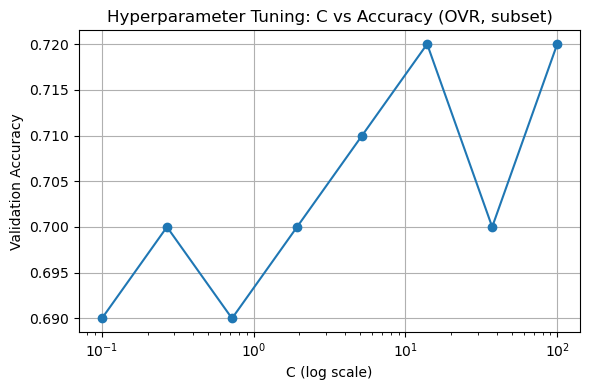

In [37]:

np.random.seed(42)
subset_idx = np.random.choice(len(X_train), size=400, replace=False)
X_sub = X_train[subset_idx]
y_sub = y_train[subset_idx]

X_sub_tr, X_sub_val, y_sub_tr, y_sub_val = train_test_split(
    X_sub, y_sub, test_size=0.25, random_state=42, stratify=y_sub
)

C_values = np.logspace(-1, 2, 8)   
val_accs = []

print(f"{'C':>10}  {'Val Acc':>10}")
print("-" * 24)
for C in C_values:
    ovr_c = OVR_SVM(C=C, kernel=nonlinear_kernel)
    ovr_c.fit(X_sub_tr, y_sub_tr)
    acc = ovr_c.score(X_sub_val, y_sub_val)
    val_accs.append(acc)
    print(f"{C:>10.3f}  {acc:>10.4f}")

best_C = C_values[np.argmax(val_accs)]
print(f"\nBest C = {best_C:.3f}  (val acc = {max(val_accs):.4f})")
print(f"(BEST_C used for full training above was set to {BEST_C})")

# Plot C vs validation accuracy
plt.figure(figsize=(6, 4))
plt.semilogx(C_values, val_accs, marker='o')
plt.xlabel("C (log scale)")
plt.ylabel("Validation Accuracy")
plt.title("Hyperparameter Tuning: C vs Accuracy (OVR, subset)")
plt.grid(True)
plt.tight_layout()
plt.show()


## Task 5:
In addition to calculating percent accuracy, generate multiclass [confusion matrices](https://en.wikipedia.org/wiki/confusion_matrix) as part of your analysis.

In [38]:

predictions = ovr.predict(X_test)


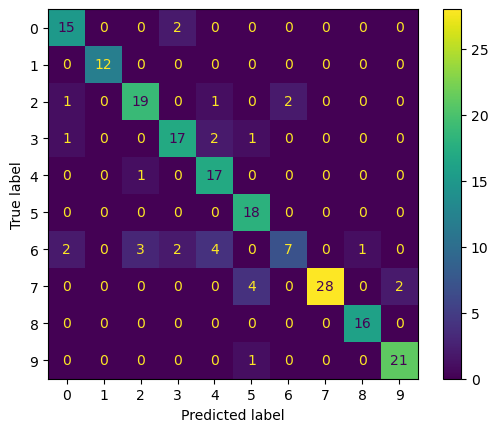

In [39]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(test_samples_labels,predictions, labels=np.unique(test_samples_labels))
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels=np.unique(test_samples_labels))
import matplotlib.pyplot as plt
cm_display.plot()
plt.show()

### What to Submit
Please submit the following:

1. A Jupyter noteboon that contains your completed notebook, where the output of each cell is clearly displayed.

2. A brief write-up that answers the 5 questions posed in this lab and justifies your model. Ensure that any figures you create are accessible and easy to understand.